In [2]:
import torch
print(torch.cuda.is_available())

True


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

import transformers
from transformers import pipeline, AutoModel, AutoModelForCausalLM, AutoModel

/root/fine_tune/ktl101/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# import kagglehub
# import pandas as pd
# import os

# path = kagglehub.dataset_download(
#     "zoya77/multi-class-sentiment-tweet-analysis-dataset"
# )

# print("Downloaded to:", path)
# print("Files:", os.listdir(path))

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/twitter_multi_class_sentiment.csv")
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [6]:
df['Sent_len']=df['text'].str.split().apply(len)
df


,text,label,label_name,Sent_len
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,24
15996,i am now turning and i feel pathetic that i am...,0,sadness,20
15997,i feel strong and good overall,1,joy,6
15998,i feel like this was such a rude comment and i...,3,anger,14


# Normal Data Analysis

In [7]:
df.isna().sum()

text          0
label         0
label_name    0
Sent_len      0
dtype: int64

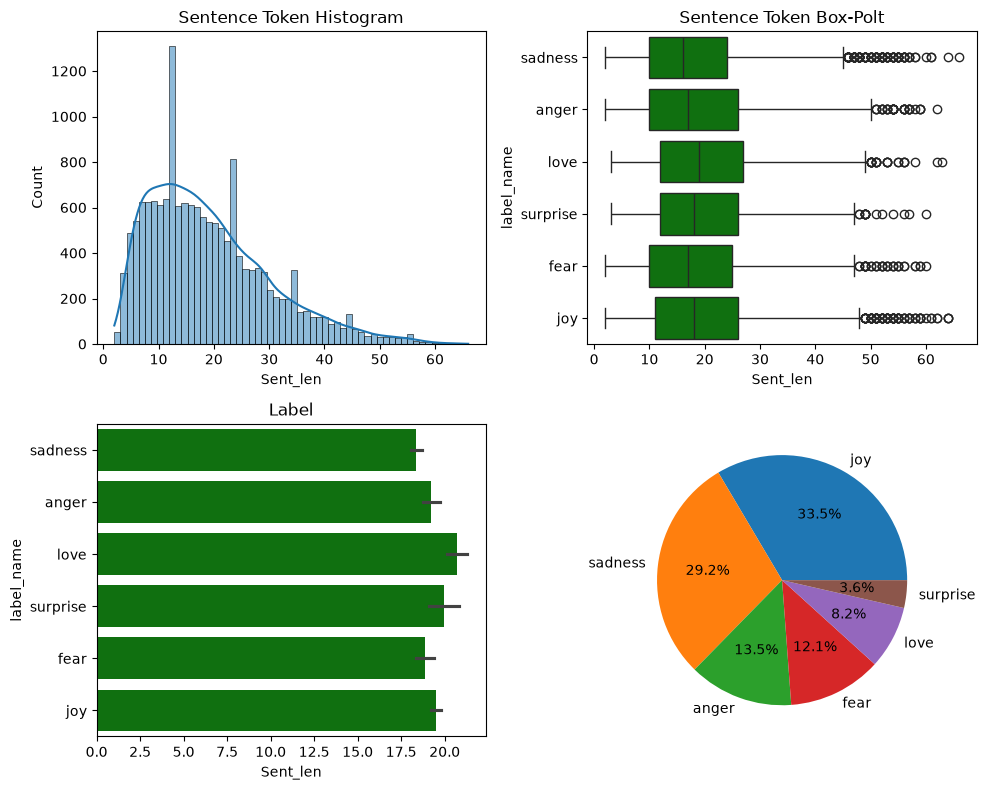

In [8]:

fig, axs = plt.subplots(2,2, figsize=(10,8))

sns.histplot(data=df, x='Sent_len', kde=True, ax=axs[0,0])
axs[0,0].set_title("Sentence Token Histogram")

sns.boxplot(data=df, x='Sent_len',y='label_name' ,ax=axs[0,1], color='green')
axs[0,1].set_title("Sentence Token Box-Polt")


sns.barplot(data=df, x='Sent_len',y='label_name' ,ax=axs[1,0], color='green')
axs[1,0].set_title("Sentence Token Bar")

counts=df['label_name'].value_counts()
axs[1,1].pie(counts, labels=counts.index, autopct='%1.1f%%')
axs[1,0].set_title("Label")

plt.tight_layout()
plt.show()

# Convert Text to Embedding 

In [9]:

from transformers import AutoTokenizer

model_check_point = 'bert-base-uncased'


tokenizer = AutoTokenizer.from_pretrained(model_check_point)

text="How are you"

tokenizer(text)

{'input_ids': [101, 2129, 2024, 2017, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}

In [10]:
# Total Vocab size 
len(tokenizer.vocab)

30522

# Train Test Split and Validation




In [11]:
from sklearn.model_selection import train_test_split as tts 
train, test = tts(df, test_size=0.3, stratify=df['label_name'])

test, val = tts(test, test_size=1/3, stratify=test['label_name'])

print(train.shape, test.shape, val.shape, df.shape)


(11200, 4) (3200, 4) (1600, 4) (16000, 4)


# Transformer Can't consume data with raw panads we need to give a proper structure to it through dataset class of transforemer

In [12]:
from datasets import Dataset, DatasetDict


# Make the data in proper format
train_data= Dataset.from_pandas(train, preserve_index=False)
train_data_small=train_data.select(range(11200))
print(train_data_small)



test_data=Dataset.from_pandas(test, preserve_index=False)
test_data_small=test_data.select(range(3200))

val_data=Dataset.from_pandas(val, preserve_index=False)
val_data_small=val_data.select(range(1600))

Dataset({
    features: ['text', 'label', 'label_name', 'Sent_len'],
    num_rows: 11200
})


In [13]:

# Create the data set

data_set = DatasetDict({
    "train": train_data_small,
    'test': test_data_small,
    'validation': val_data_small
})

In [14]:
# See the data
data_set['train']

Dataset({
    features: ['text', 'label', 'label_name', 'Sent_len'],
    num_rows: 11200
})

# Tokenization of the Data

In [15]:
def tokenize_data(batch):
    temp=tokenizer(batch['text'], padding=True, truncation=True)
    return temp 


print("################# Test The Function ############")
print()
print(tokenize_data(data_set['train'][:2]))

################# Test The Function ############

{'input_ids': [[101, 1045, 2293, 2129, 3730, 2027, 2191, 2026, 2606, 2514, 1998, 2009, 3957, 2026, 2606, 1037, 8403, 3019, 2559, 12342, 2000, 2009, 102], [101, 1045, 2572, 2196, 3407, 2005, 1996, 2477, 1045, 2079, 2031, 1045, 2514, 2061, 4895, 22780, 3993, 2005, 2008, 102, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]]}


In [16]:
emotion_encoded=data_set.map(tokenize_data, batched=True, batch_size=None)


Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map: 100%|██████████| 1600/1600 [00:00<00:00, 21984.81 examples/s]


In [17]:
emotion_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'Sent_len', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'Sent_len', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'Sent_len', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1600
    })
})

# Label2id and id2labels for latter usage

In [36]:
label2id = {x['label_name']:x['label']   for x in data_set['train']}
id2label= {v:k for k,v in label2id.items()}
print(label2id)
print(id2label)
train_labels = data_set['train']['label']
print(train_labels)

{'love': 2, 'sadness': 0, 'fear': 4, 'joy': 1, 'surprise': 5, 'anger': 3}
{2: 'love', 0: 'sadness', 4: 'fear', 1: 'joy', 5: 'surprise', 3: 'anger'}
Column([2, 0, 0, 4, 1, ...])


# Model Building

In [19]:
from transformers import AutoModel
import torch 

In [20]:
model = AutoModel.from_pretrained(model_check_point)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 583.25it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


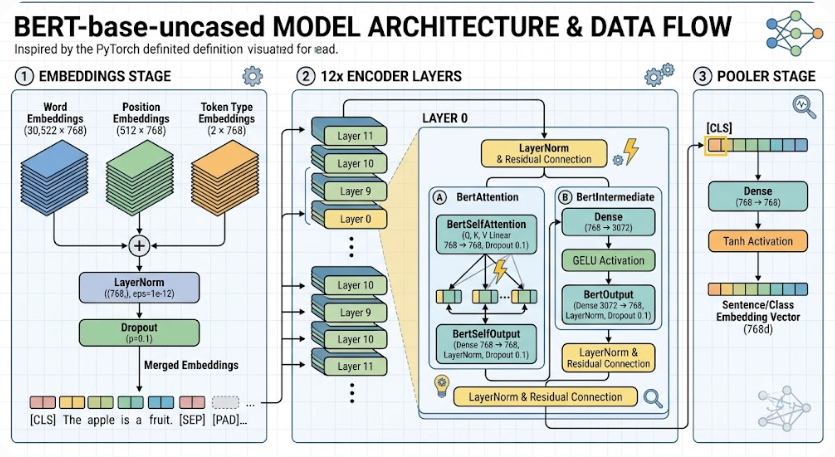

In [21]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

# Now we Will add a Classification Head 

In [22]:
from transformers import AutoModelForSequenceClassification, AutoConfig

num_labels=len(label2id)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [23]:
# Config 
config = AutoConfig.from_pretrained(
    pretrained_model_name_or_path = model_check_point, label2id=label2id, id2label=id2label
)

#model with the classification head

model_cls = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path=model_check_point,
    config=config,
).to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3157.54it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

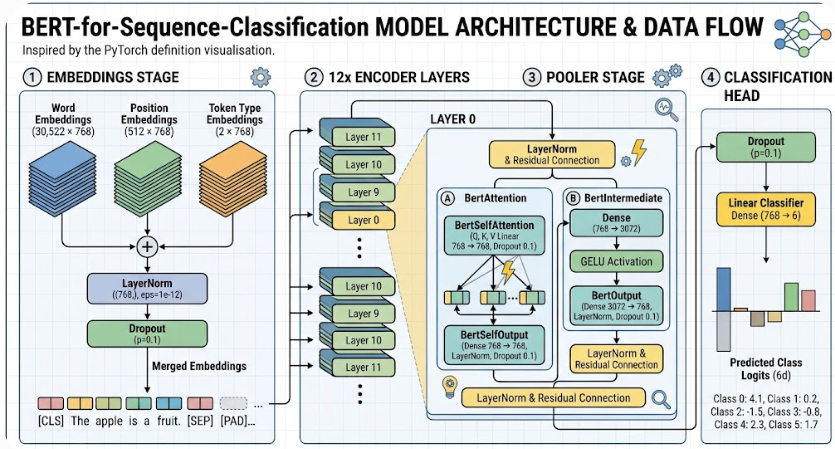

In [24]:
model_cls

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

# Training Argument 

# Data Has Imbalnce need to fix the imbalanceness

In [39]:
import torch
from torch.nn import CrossEntropyLoss
from transformers import Trainer

# Class weights calculate karo (jitna kam samples, utna zyada weight)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),   # apne actual train labels array se
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to("cuda")

# Custom Trainer banao jo weighted loss use kare
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to("cuda")

print(class_weights) 


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

tensor([0.5715, 0.4972, 2.0445, 1.2354, 1.3766, 4.6667], device='cuda:0')


In [25]:
from transformers import TrainingArguments

batch_size = 64 
training_arg = TrainingArguments(
    output_dir='/ktl_model_bert',
    num_train_epochs=3, 
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    disable_tqdm=False
)

# Compute Metrix

### Using Evaluate

In [26]:
from sklearn.metrics import *
import evaluate

accuracy = evaluate.load("accuracy")


def compute_metric_evaluate(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# Using Sklearn metrix

In [27]:
def compute_metric_sklearn(pred):
    labels = pred.label_ids
    preds=pred.predictions.argmax(-1)
    f1=f1_score(y_true=labels, y_pred=preds, average='weighted')
    acc=accuracy_score(labels, preds)

    return {"Accuracy": acc, "f1-score": f1}

# Trainer 

In [43]:

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", 
    num_labels=6   
)


trainer = WeightedTrainer(
    model=model,
    args=training_arg,
    train_dataset=emotion_encoded['train'],
    eval_dataset=emotion_encoded['validation'],
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 531.39it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoin

In [44]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.510675
2,No log,0.250349
3,0.623191,0.225547


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]


TrainOutput(global_step=525, training_loss=0.6025547045753116, metrics={'train_runtime': 113.0454, 'train_samples_per_second': 297.226, 'train_steps_per_second': 4.644, 'total_flos': 1502253632275200.0, 'train_loss': 0.6025547045753116, 'epoch': 3.0})

# Prediction/Evaluation

In [45]:
output=trainer.predict(emotion_encoded['test'])
output.metrics

{'test_loss': 0.21378068625926971,
 'test_runtime': 3.2255,
 'test_samples_per_second': 992.098,
 'test_steps_per_second': 15.502}

In [46]:
y_pred=np.argmax(output.predictions,axis=1)
len(y_pred)

3200

In [47]:
y_true=emotion_encoded['test'][:]['label']
len(y_true)

3200

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_pred=y_pred, y_true=y_true))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       933
           1       0.99      0.87      0.93      1072
           2       0.75      0.97      0.85       261
           3       0.91      0.96      0.93       432
           4       0.88      0.86      0.87       387
           5       0.69      0.96      0.80       115

    accuracy                           0.92      3200
   macro avg       0.86      0.93      0.89      3200
weighted avg       0.93      0.92      0.92      3200



# Confusion Metrix

<Axes: >

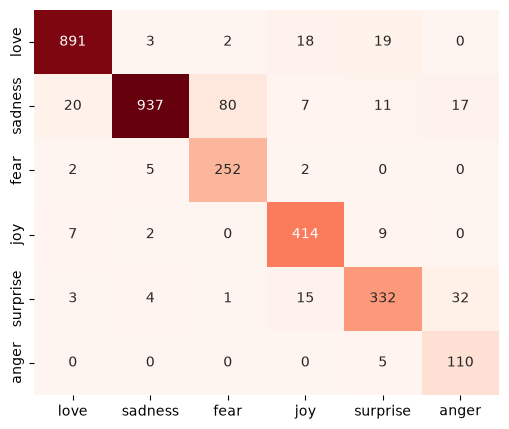

In [49]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_true=y_true, y_pred=y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=label2id.keys(), yticklabels=label2id.keys(), cbar=False)
